# Lab 7 — Full Engagement: The Autofill Decision
# المعمل 7 — دراسة حالة متكاملة: قرار الإكمال التلقائي

**Module 7 — Experimentation Case Study**
**الوحدة 7 — دراسة حالة تطبيقية في التجريب**

*SDA-DSC-213 · SDAIA Academy · Day 4, Hour 2 · 50 minutes · dress rehearsal for the capstone*

---

## The engagement

The Injaz Product & Policy Committee meets in ten days. Two decisions are on the agenda and
they arrive as one question:

> *"Should we launch AI-assisted form autofill nationally, and did last year's reminder pilot
> justify extending it?"*

Nobody labelled this "use DiD." One limb is a **future feature you can randomise**. The other
is a **past pilot you cannot**. Your value is choosing correctly, executing correctly, and
translating both into a recommendation a director can act on.

The engagement runs in a fixed order, and skipping steps is where credibility leaks:

```
1 FRAME  ->  2 DESIGN  ->  3 POWER  ->  [FREEZE]  ->  4 ANALYSE  ->  5 VALIDATE  ->  6 DECIDE
   \________ before you see any outcome ________/      \__ follow the frozen plan __/
```

| | |
|---|---|
| **Objective** | Sequence a full engagement, analyse the autofill A/B with CUPED and guardrails, reconcile it with the quasi-experimental evidence, and produce a decision memo |
| **Data** | `injaz_autofill_ab.csv` (70,000), `injaz_traffic_forecast.csv`, `injaz_regions_panel.csv`, `injaz_users.csv` |
| **Decision threshold** | **+1.0 pp** on completion — below that the build and inference cost is not recovered |
| **Graded skill** | **judgement**, not code |

### Bilingual key terms (first use)

| English | العربية |
|---|---|
| Frozen analysis plan | خطة تحليل مُجمّدة |
| Overall evaluation criterion (OEC) | معيار التقييم الشامل |
| Guardrail metric | مؤشر حماية |
| Practical significance | الدلالة العملية |
| Decision memo | مذكرة قرار |


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make `causal_utils` importable from anywhere under course_assets/
ROOT = Path.cwd()
while not (ROOT / "causal_utils").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
DATA = ROOT / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from causal_utils import use_sdaia_style
use_sdaia_style()

RANDOM_SEED = 213          # fixed for every lab: reproducibility is graded
rng = np.random.default_rng(RANDOM_SEED)
print("Environment ready ·", ROOT)

Environment ready · /home/claude/course_assets


In [2]:
# --- lab scaffolding: self-checks that never crash the notebook ----------
def check(name, fn):
    """Run a self-check. Prints PASS/FAIL/TODO instead of raising, so the
    notebook always runs top-to-bottom even with unfinished exercises."""
    try:
        fn()
    except AssertionError as e:
        print(f"[ TODO ]  {name}: {e}")
        return False
    except Exception as e:
        print(f"[ ERROR ] {name}: {type(e).__name__}: {e}")
        return False
    print(f"[  OK  ]  {name}")
    return True


def needs(*objs, msg="complete the TODO cell above first"):
    """Guard downstream cells so an unfinished TODO skips rather than crashes."""
    if any(o is None for o in objs):
        print(f"[ SKIPPED ] {msg}")
        return False
    return True

print("Scaffolding loaded: use check(...) to self-test and needs(...) to guard.")

Scaffolding loaded: use check(...) to self-test and needs(...) to guard.


## Step 0 — Method selection *(3 min)*

Before anything else: **which method, and why?** The selection follows the data situation,
never preference.

| Question | Data situation | Method |
|---|---|---|
| Can we randomise going forward? | yes → **A/B test** — always the first choice |
| Did a treatment turn on at a known time for some units? | yes → **difference-in-differences** |
| Is there an as-good-as-random source of variation? | yes → **instrumental variables** |
| Only cross-sectional data with measured confounders? | → **matching / weighting** + sensitivity |
| No measured way to close the backdoors? | → **declare it not identifiable** |

Run the drill below on six one-line Injaz questions before you touch the data.

In [3]:
DRILL = {
    "Should we launch autofill nationally next quarter?":                       "ab_test",
    "Did last year's region-by-region reminder rollout raise completion?":       "did",
    "Does filing online rather than in person raise completion?":                "iv",
    "Did the voluntary training programme help those who took it?":              "matching",
    "Do users who contact support complete more often, and should we push them?": "not_identifiable",
    "Does a redesigned upload step raise completion?":                            "ab_test",
}
ANSWER_KEY = ["ab_test", "did", "iv", "matching", "not_identifiable", "ab_test"]

JUSTIFY = {
    "ab_test": "we control the rollout going forward, so randomise - nothing else is cheaper",
    "did": "treatment turned on at a KNOWN time for SOME units; not-yet-treated regions "
           "are the control",
    "iv": "channel choice is confounded by unmeasured motivation, but distance to a "
          "service centre shifts channel and (we argue) nothing else",
    "matching": "cross-sectional, self-selected, with the main confounders measured - "
                "so match and then bound the hidden bias",
    "not_identifiable": "support contact is a CONSEQUENCE of struggling, not a manipulable "
                        "treatment. 'Push them' is a different, randomisable question - "
                        "ask which one they mean",
}
for q, m in DRILL.items():
    print(f"{m:<18} {q}\n{'':<18} -> {JUSTIFY[m]}\n")

def _c():
    got = list(DRILL.values())
    assert all(v is not None for v in got), "fill in all six"
    assert got == ANSWER_KEY, f"got {got}"
check("method-selection drill 6/6", _c)

ab_test            Should we launch autofill nationally next quarter?
                   -> we control the rollout going forward, so randomise - nothing else is cheaper

did                Did last year's region-by-region reminder rollout raise completion?
                   -> treatment turned on at a KNOWN time for SOME units; not-yet-treated regions are the control

iv                 Does filing online rather than in person raise completion?
                   -> channel choice is confounded by unmeasured motivation, but distance to a service centre shifts channel and (we argue) nothing else

matching           Did the voluntary training programme help those who took it?
                   -> cross-sectional, self-selected, with the main confounders measured - so match and then bound the hidden bias

not_identifiable   Do users who contact support complete more often, and should we push them?
                   -> support contact is a CONSEQUENCE of struggling, not a manipulable tr

True

> ### Instructor note — Step 0
>
> **Teaching point.** Run this as a 3-minute speed round with the class calling answers out.
> The only one that reliably splits the room is #5 — participants want to answer "matching."
> Push: *what is the treatment? when is it delivered? who decides?* Support contact is not
> something Injaz assigns; it is a symptom. The professionally useful move is to reframe the
> question into one that has an answer ("if we proactively call struggling users, does
> completion rise?" — randomisable).
>
> **Common wrong answer.** #3 answered "matching." Matching cannot help when the confounder
> (motivation) is unmeasured; that is precisely when you reach for an instrument.

## Step 1 — Frame and freeze the analysis plan *(8 min)*

Everything in this cell is committed **before any outcome is observed**. The freeze is the
whole point: metrics chosen after seeing data are not metrics, they are conclusions with a
p-value stapled on.

`freeze_plan()` timestamps and hashes the plan. The hash goes in the memo so a reader can
verify nothing moved.

In [4]:
from causal_utils import AnalysisPlan, freeze_plan

plan = AnalysisPlan(
    experiment_name="injaz_autofill_v1",
    decision=("Launch AI-assisted form autofill to all Injaz users, or hold and keep "
              "running? Launch requires a completion gain of at least +1.0 pp, the point "
              "at which the inference cost and support burden are recovered."),
    randomisation_unit="user_id",
    oec="completion_rate among TRIGGERED users",
    guardrails=["support_contact", "error_flag", "drop_off", "session_duration_sec"],
    trigger_definition=("a user reaches a form step where at least one field is eligible "
                        "for autofill; users who never reach such a step cannot be "
                        "affected and are excluded from the OEC"),
    unit_of_analysis="user (one row per user; matches the randomisation unit)",
    mde=0.010,
    alpha=0.05,
    power=0.80,
    correction_family="none for the OEC (single pre-registered metric); "
                      "Bonferroni across the 4-metric guardrail family",
    stopping_rule="fixed horizon; no interim stopping for significance; no peeking",
    practical_threshold=0.010,
)
plan = freeze_plan(plan)
print("\n" + plan.to_json())

def _c():
    assert plan is not None, "plan is still None"
    assert len(plan.guardrails) >= 3, "at least three guardrails are required"
    assert plan.practical_threshold == 0.010, "the decision threshold is 1.0 pp"
    assert plan.plan_hash is not None, "you must call freeze_plan(plan)"
check("analysis plan complete and frozen", _c)

Analysis plan FROZEN at 2026-09-07T17:21:39+00:00
  hash: ca010dcd9d5a1387

{
  "alpha": 0.05,
  "correction_family": "none for the OEC (single pre-registered metric); Bonferroni across the 4-metric guardrail family",
  "decision": "Launch AI-assisted form autofill to all Injaz users, or hold and keep running? Launch requires a completion gain of at least +1.0 pp, the point at which the inference cost and support burden are recovered.",
  "experiment_name": "injaz_autofill_v1",
  "frozen_at": "2026-09-07T17:21:39+00:00",
  "guardrails": [
    "support_contact",
    "error_flag",
    "drop_off",
    "session_duration_sec"
  ],
  "mde": 0.01,
  "oec": "completion_rate among TRIGGERED users",
  "plan_hash": "ca010dcd9d5a1387",
  "planned_n_per_arm": null,
  "planned_run_days": null,
  "power": 0.8,
  "practical_threshold": 0.01,
  "randomisation_unit": "user_id",
  "stopping_rule": "fixed horizon; no interim stopping for significance; no peeking",
  "trigger_definition": "a user reaches a

True

> ### Instructor note — Step 1
>
> **Teaching point.** Three design choices carry all the weight here, and each is worth
> naming aloud:
> 1. **The OEC is defined on TRIGGERED users.** Assigning 70,000 users but only 49,510
>    reaching an autofillable field means an all-assigned analysis dilutes the effect by the
>    trigger rate. Step 3 measures the damage.
> 2. **Unit of analysis == randomisation unit.** Both are the user. Analyse sessions instead
>    and the standard errors are fiction (Module 2).
> 3. **The correction family is a design decision.** One pre-registered OEC needs no
>    correction; four guardrails need Bonferroni, because you want to be *sure* none is broken.
>
> **Common wrong answer.** Setting `mde` to whatever the observed effect turns out to be. If
> a pair edits the plan after Step 3, that is exactly the anti-pattern the hash exists to
> expose — and in the capstone rubric it caps the design criterion at 70%.

## Step 2 — Power and sizing *(8 min)*

**Before** the data. Can the experiment we are about to run actually detect the effect we
care about? Three things bite teams here: *n* is per arm, not every eligible user triggers,
and a run length must be a whole number of weeks (KSA weekend traffic is a different
population).

**On the run-length floor.** `run_length` rounds up to whole weeks because weekday and
weekend users are different people: Friday and Saturday traffic is about 58% of a weekday's,
so a run that stops mid-week samples a biased slice. Here the arithmetic alone asks for
10 days, which rounds up to **14 days — two whole weeks**, the same floor Lab 3 imposed
explicitly. Read the plan below against that number, not against the raw arithmetic.

In [5]:
from causal_utils import (sample_size_proportions, run_length, cuped_adjust,
                          power_for_n, mde_for_n)

ab = pd.read_csv(DATA / "injaz_autofill_ab.csv")
traffic = pd.read_csv(DATA / "injaz_traffic_forecast.csv")
triggered = ab[ab["triggered"] == 1].copy()

baseline = float(triggered.loc[triggered["variant"] == "control", "completed"].mean())
n_required = sample_size_proportions(baseline, plan.mde, alpha=plan.alpha, power=plan.power)
rl = run_length(n_required,
                daily_eligible=float(traffic["eligible_users"].mean()),
                trigger_rate=float(traffic["trigger_rate"].mean()))

print(f"baseline completion (triggered control) : {baseline:.4f}")
print(f"MDE from the frozen plan                : {100*plan.mde:+.1f} pp")
print(f"required n per arm                      : {n_required:,}\n")
print(rl)

def _c():
    assert baseline is not None and n_required is not None and rl is not None,         "fill in baseline / n_required / rl"
    assert 0.50 < baseline < 0.60, "baseline completion should be around 55%"
    assert 30_000 < n_required < 50_000, "n per arm at a 1.0 pp MDE should be ~39,000"
check("sizing computed", _c)

baseline completion (triggered control) : 0.5506
MDE from the frozen plan                : +1.0 pp
required n per arm                      : 38,758

Run-length plan
  required per arm      : 38,758
  arms                  : 2
  total units needed    : 77,516
  daily eligible        : 13,410
  trigger rate          : 62.0%
  daily usable units    : 8,319
  days by arithmetic    : 10
  weekly-cycle floor    : 7
  ==> RUN FOR           : 14 days
[  OK  ]  sizing computed


True

### Step 2b — CUPED saving, and the uncomfortable arithmetic

CUPED uses a **pre-treatment** covariate to strip variance out of the outcome. Variance falls
by ρ², so the effective sample rises — for free, and without bias, provided the covariate
cannot have been affected by treatment.

Then compare what you *needed* against what you *have*. This is the cell that determines the
verdict at the end of the lab, and most teams skip it.

In [6]:
cuped = cuped_adjust(triggered["completed"].to_numpy(),
                     triggered["prior_completion_rate"].to_numpy())
print(cuped)

n_cuped = int(np.ceil(n_required / cuped.effective_n_multiplier))
rl_cuped = run_length(n_cuped,
                      daily_eligible=float(traffic["eligible_users"].mean()),
                      trigger_rate=float(traffic["trigger_rate"].mean()))
print(f"\nrequired n per arm, plain : {n_required:,}   ({rl.days_recommended} days)")
print(f"required n per arm, CUPED : {n_cuped:,}   ({rl_cuped.days_recommended} days)")
print(f"CUPED saving              : {100*(1 - n_cuped/n_required):.1f}% of the sample")

n_actual = int(triggered["variant"].value_counts().min())
mde_actual = mde_for_n(n_actual, baseline, alpha=plan.alpha, power=plan.power)

print("\n" + "=" * 68)
print("THE UNCOMFORTABLE ARITHMETIC")
print("=" * 68)
print(f"  n needed per arm to resolve a {100*plan.mde:.1f} pp effect : {n_required:,}")
print(f"  n actually collected per arm (triggered)      : {n_actual:,}")
print(f"  shortfall                                     : "
      f"{100*(1 - n_actual/n_required):.0f}%")
print(f"  smallest effect this run CAN resolve          : {100*mde_actual:+.2f} pp")
print(f"  decision threshold                            : {100*plan.mde:+.2f} pp")
print("\n  The experiment was stopped short of its own design. It can distinguish")
print(f"  {100*mde_actual:.2f} pp from zero, but it CANNOT distinguish an effect above the")
print(f"  {100*plan.mde:.1f} pp threshold from one below it. Predict now what the")
print("  confidence interval will do - then look.")
print(f"\n  power against the design MDE at this n: "
      f"{power_for_n(n_actual, baseline, plan.mde):.0%}  (planned {plan.power:.0%})")

def _c():
    assert cuped is not None and n_actual is not None and mde_actual is not None,         "fill in cuped / n_actual / mde_actual"
    assert 0.12 < cuped.variance_reduction < 0.17, "CUPED should buy roughly 14%"
    assert mde_actual > plan.mde, ("this experiment cannot resolve its own threshold - "
                                   "that is the finding, not an error")
check("CUPED quantified; the experiment is under-run for its own threshold", _c)

CUPED variance reduction
  corr(pre, post)      : 0.378
  theta                : 0.9124
  variance before/after: 0.24671 -> 0.21142
  variance reduction   : 14.3%
  equivalent to        : 1.17x the sample

required n per arm, plain : 38,758   (14 days)
required n per arm, CUPED : 33,215   (14 days)
CUPED saving              : 14.3% of the sample

THE UNCOMFORTABLE ARITHMETIC
  n needed per arm to resolve a 1.0 pp effect : 38,758
  n actually collected per arm (triggered)      : 24,736
  shortfall                                     : 36%
  smallest effect this run CAN resolve          : +1.25 pp
  decision threshold                            : +1.00 pp

  The experiment was stopped short of its own design. It can distinguish
  1.25 pp from zero, but it CANNOT distinguish an effect above the
  1.0 pp threshold from one below it. Predict now what the
  confidence interval will do - then look.

  power against the design MDE at this n: 61%  (planned 80%)
[  OK  ]  CUPED quantified; the e

True

> ### Instructor note — Step 2
>
> **This is the most important cell in the lab.** Stop here and make the class *predict* the
> confidence interval before Step 3 reveals it. The design needed **38,758 per arm**; the
> experiment collected **24,736**. The smallest effect this run can resolve is **1.25 pp**,
> against a **1.0 pp** threshold. The interval *must* straddle the threshold — it is
> arithmetic, decided before anyone looked at an outcome.
>
> Participants who do this step properly reach Step 6 already knowing the answer is HOLD, and
> can defend it as a **design** conclusion rather than a p-value reading. That distinction is
> the difference between the 90–100% and the 70–89% band on the capstone's power criterion.
>
> **Common wrong answer.** "Power is 88%, so we are fine." Power against **+1.4 pp** is 88%;
> power against the **+1.0 pp** decision threshold is what matters, and "80% powered" is an
> incomplete sentence without an effect size attached.
>
> **Expected output.** CUPED variance reduction 14.3%, effective-n multiplier 1.17×, saving
> 14.3% of the sample (38,758 → 33,215 per arm).

## Step 3 — Experiment integrity: SRM and balance *(6 min)*

Before any effect estimate. An experiment that fails these is **invalid** and must not be
analysed — the correct response is to find the bug, not to adjust and continue.

In [7]:
from causal_utils import srm_check, balance_table

BALANCE_COVS = ["age", "device_age_years", "prior_sessions", "prior_completion_rate",
                "digital_literacy_score", "region", "device"]
srm_all = srm_check(ab["variant"])
srm_trig = srm_check(triggered["variant"])
bal = balance_table(triggered, "variant", BALANCE_COVS)

print("ALL ASSIGNED")
print(srm_all)
print("\nTRIGGERED SUBSET  (the population the OEC is defined on)")
print(srm_trig)
print("\nCOVARIATE BALANCE — worst 6 of "
      f"{len(bal)} rows (categoricals expanded per level)")
print(bal.head(6).to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(f"\nworst |SMD| = {bal['abs_smd'].max():.4f}   "
      f"({'PASS' if bal['abs_smd'].max() < 0.10 else 'FAIL'}, threshold 0.10)")
print("\nNote we checked SRM on the TRIGGERED subset too. Triggering happens AFTER")
print("assignment, so a bug in trigger logging could break the randomisation even")
print("though the assignment itself was clean. It did not here - but check, always.")

def _c():
    assert srm_all is not None and srm_trig is not None and bal is not None,         "run all three checks"
    assert srm_all.passed and srm_trig.passed, "SRM failed - the experiment is invalid"
    assert bal["abs_smd"].max() < 0.10, "a covariate is imbalanced"
check("integrity: SRM passes and every |SMD| < 0.1", _c)

ALL ASSIGNED
Sample Ratio Mismatch check: PASS
  chi2 = 0.01   p = 0.904
  control      observed   35,016   expected     35,000   (+0.05%)
  treatment    observed   34,984   expected     35,000   (-0.05%)

TRIGGERED SUBSET  (the population the OEC is defined on)
Sample Ratio Mismatch check: PASS
  chi2 = 0.03   p = 0.864
  control      observed   24,774   expected     24,755   (+0.08%)
  treatment    observed   24,736   expected     24,755   (-0.08%)

COVARIATE BALANCE — worst 6 of 21 rows (categoricals expanded per level)
              covariate  mean_treatment  mean_control     smd  abs_smd  balanced
            region=Hail         +0.0215       +0.0189 +0.0186  +0.0186      True
       device_age_years         +2.9851       +2.9653 +0.0156  +0.0156      True
          region=Riyadh         +0.2564       +0.2617 -0.0121  +0.0121      True
region=Northern Borders         +0.0099       +0.0088 +0.0119  +0.0119      True
 digital_literacy_score         +0.7043       +0.7060 -0.0111  +0.

True

> ### Instructor note — Step 3
>
> **Teaching point.** The second SRM check — on the *triggered* subset — is the one most
> teams omit and the one that catches real production bugs. Assignment can be perfect while
> trigger logging silently drops one arm's events.
>
> **If a pair wants to see a failure**, point them at `injaz_experiment_results_srm_broken.csv`
> from Module 2: chi² ≈ 16.5, p ≈ 4.8 × 10⁻⁵, and the correct action is to stop.
>
> **Expected output.** All-assigned χ² = 0.01, p = 0.90 (pass); triggered χ² = 0.03, p = 0.86
> (pass); worst |SMD| = 0.019.

## Step 4 — Analyse: the OEC *(10 min)*

Now, and only now, look at outcomes — following the frozen plan, not improvising.

Three estimates to produce:

1. the **raw** difference on triggered users (the plan's OEC),
2. the **CUPED-adjusted** estimate with robust SEs — the plan's primary,
3. the **all-assigned** estimate, as a demonstration of the dilution trap.

In [8]:
from causal_utils import two_proportion_test, regression_effect

eff_raw = two_proportion_test(triggered, "completed", "variant",
                              label="Autofill · completion (triggered, raw)")
triggered["completed_cuped"] = cuped.y_adjusted
eff_cuped = regression_effect(triggered, "completed_cuped", "variant",
                              cov_type="HC3",
                              label="Autofill · completion (triggered, CUPED)")
eff_all = two_proportion_test(ab, "completed", "variant",
                              label="Autofill · completion (ALL assigned - diluted)")

for e in (eff_raw, eff_cuped, eff_all):
    print(e); print()

print("=" * 68)
print(f"CUPED narrowed the interval from {100*(eff_raw.ci_high - eff_raw.ci_low):.2f} pp "
      f"wide to {100*(eff_cuped.ci_high - eff_cuped.ci_low):.2f} pp wide "
      f"({100*(1 - eff_cuped.se/eff_raw.se):.0f}% less standard error) "
      f"\nfor no extra data and no bias - the covariate is pre-treatment.")
print(f"\nTHE DILUTION TRAP: analysing all {len(ab):,} assigned users instead of the "
      f"{len(triggered):,}\ntriggered ones gives {100*eff_all.estimate:+.2f} pp instead of "
      f"{100*eff_raw.estimate:+.2f} pp - the effect is\nspread across users who could not "
      f"possibly have been affected (trigger rate {ab['triggered'].mean():.1%}).")

def _c():
    assert eff_raw is not None and eff_cuped is not None and eff_all is not None,         "produce all three estimates"
    assert eff_cuped.se < eff_raw.se, "CUPED should TIGHTEN the interval"
    assert eff_all.estimate < eff_raw.estimate, "the all-assigned estimate should be diluted"
check("OEC estimated three ways; CUPED tightens, all-assigned dilutes", _c)

Autofill · completion (triggered, raw) (two-proportion z-test)
  effect : +1.37 pp [+0.49, +2.24]   (95% CI)
  se     : 0.00446    p = 0.002213
  n      : treatment 24,736 / control 24,774

Autofill · completion (triggered, CUPED) (OLS + HC3 robust SE)
  effect : +1.57 pp [+0.76, +2.38]   (95% CI)
  se     : 0.00413    p = 0.0001453
  n      : treatment 24,736 / control 24,774

Autofill · completion (ALL assigned - diluted) (two-proportion z-test)
  effect : +0.97 pp [+0.23, +1.70]   (95% CI)
  se     : 0.00376    p = 0.009959
  n      : treatment 34,984 / control 35,016

CUPED narrowed the interval from 1.75 pp wide to 1.62 pp wide (7% less standard error) 
for no extra data and no bias - the covariate is pre-treatment.

THE DILUTION TRAP: analysing all 70,000 assigned users instead of the 49,510
triggered ones gives +0.97 pp instead of +1.37 pp - the effect is
spread across users who could not possibly have been affected (trigger rate 70.7%).
[  OK  ]  OEC estimated three ways; CUPED

True

> ### Instructor note — Step 4
>
> **Teaching point.** CUPED is free money and participants under-use it: 7% less standard
> error here, equivalent to ~17% more sample. The one condition — the covariate must be
> pre-treatment — is the entire safety argument. `prior_completion_rate` qualifies;
> `session_duration_sec` from this experiment does not.
>
> **Common wrong answer.** Reading the all-assigned estimate as "the effect on the business."
> It is neither: the causal effect is on triggered users, and the business-wide impact is that
> effect *times* the trigger rate — a separate calculation that belongs in the memo, not a
> substitute for the estimate.
>
> **Expected output.** raw **+1.37 pp** [+0.49, +2.24]; CUPED **+1.57 pp** [+0.76, +2.38];
> all-assigned **+0.97 pp** — exactly the trigger rate (0.7073) times the planted +1.40 pp,
> and now *below* the +1.0 pp bar, so the trap flips the verdict.

## Step 5 — Guardrails, with the correct correction family *(6 min)*

Four guardrails were pre-registered. The family is four tests, so **Bonferroni** — you want to
be confident that *none* is broken (FWER), not that most are fine (FDR).

Direction matters as much as significance. A drop in `drop_off` is an *improvement*; a rise in
`support_contact` is a *harm*.

In [9]:
from causal_utils import correct_pvalues

guardrail_effects = [
    regression_effect(triggered, m, "variant", cov_type="HC3", label=m)
    for m in plan.guardrails
]
guardrails = correct_pvalues([e.p_value for e in guardrail_effects],
                             [e.label for e in guardrail_effects],
                             method="bonferroni", alpha=plan.alpha)

detail = pd.DataFrame([{"metric": e.label, "effect": e.estimate,
                        "ci_low": e.ci_low, "ci_high": e.ci_high}
                       for e in guardrail_effects]).merge(guardrails, on="metric")
DIRECTION = {"support_contact": "higher is WORSE", "error_flag": "higher is WORSE",
             "drop_off": "higher is WORSE", "session_duration_sec": "lower is BETTER"}
detail["direction"] = detail["metric"].map(DIRECTION)
detail["verdict"] = np.where(
    ~detail["reject"], "no detectable change",
    np.where(((detail["metric"] == "session_duration_sec") & (detail["effect"] < 0))
             | ((detail["metric"] != "session_duration_sec") & (detail["effect"] < 0)),
             "moved in the GOOD direction", "*** HARM - investigate ***"))

print(detail[["metric", "effect", "ci_low", "ci_high", "p_raw", "p_adjusted",
              "reject", "direction", "verdict"]]
      .to_string(index=False, float_format=lambda v: f"{v:+.4f}"))
print(f"\nCorrection: {guardrails['method'].iat[0]} over a family of "
      f"{guardrails['family_size'].iat[0]} pre-registered guardrails.")
print("\nREAD IT CAREFULLY:")
print("  support_contact     +0.19 pp raw p = 0.283 -> adjusted p = 1.00. NOT significant")
print("                      once the family is corrected. Worth watching in a longer run,")
print("                      not a blocker.")
print("  drop_off            falls, and survives correction - autofill is helping users")
print("                      finish rather than abandoning them.")
print("  session_duration    falls by ~10 seconds - forms are faster. A benefit, and a")
print("                      reminder that a 'guardrail' can move the right way.")
print("  error_flag          unchanged.")
print("\nVERDICT: no guardrail is broken. The feature is SAFE. Whether it is WORTH")
print("         shipping is a different question, answered in Step 7.")

def _c():
    assert guardrails is not None, "guardrails is still None"
    assert len(guardrails) == len(plan.guardrails), "one row per pre-registered guardrail"
    assert (guardrails["family_size"] == len(plan.guardrails)).all(), \
        "the correction family must be the pre-registered guardrail family"
check("guardrails checked with the pre-registered correction family", _c)

              metric   effect   ci_low  ci_high   p_raw  p_adjusted  reject       direction                     verdict
     support_contact  +0.0019  -0.0016  +0.0054 +0.2826     +1.0000   False higher is WORSE        no detectable change
          error_flag  -0.0025  -0.0054  +0.0005 +0.1015     +0.4059   False higher is WORSE        no detectable change
            drop_off  -0.0134  -0.0217  -0.0052 +0.0013     +0.0053    True higher is WORSE moved in the GOOD direction
session_duration_sec -10.4319 -11.9736  -8.8902 +0.0000     +0.0000    True lower is BETTER moved in the GOOD direction

Correction: BONFERRONI over a family of 4 pre-registered guardrails.

READ IT CAREFULLY:
  support_contact     +0.19 pp raw p = 0.283 -> adjusted p = 1.00. NOT significant
                      once the family is corrected. Worth watching in a longer run,
                      not a blocker.
  drop_off            falls, and survives correction - autofill is helping users
                      fin

True

> ### Instructor note — Step 5
>
> **Teaching point.** The family contains both cases at once. `drop_off` falls 1.34 pp at
> raw p = 0.0013 and **survives** Bonferroni at adjusted p = 0.0053 — a corrected finding you
> can report. `support_contact` rises only 0.19 pp at raw p = 0.28 and goes nowhere, adjusted
> p = 1.00; had it landed near raw p = 0.04 instead, a team that forgot the correction family
> would have reported "autofill increases support contacts, kill it". Four tests, four
> chances to cross α.
>
> **Common wrong answer.** Applying BH here. BH controls the *expected proportion* of false
> discoveries — appropriate for an exploratory segment sweep, wrong for a safety family where
> a single missed harm is the failure mode you care about. The family choice is a *design*
> decision and was frozen in Step 1.
>
> **Second common error.** Reading "significant" as "bad" without checking direction.
> `drop_off` and `session_duration_sec` both moved significantly — both in the good direction.

## Step 6 — Reconcile with the observational evidence *(8 min)*

The committee is deciding on a portfolio, not a feature. Bring in the two quasi-experimental
estimates from Labs 5a and 5b so the three sit on one axis with one threshold line.

**Triangulation, not cherry-picking.** Agreement across methods that fail in *different* ways
strengthens a claim. Disagreement is itself a finding — usually a violated assumption.

In [10]:
from causal_utils import did_twfe, match_nearest

panel = pd.read_csv(DATA / "injaz_regions_panel.csv")
did_reminders = did_twfe(panel, "completion_rate", "region", "period", "treated_post")

users = pd.read_csv(DATA / "injaz_users.csv")
TRAIN_COVS = ["age", "digital_literacy_score", "prior_completion_rate",
              "prior_sessions", "device_age_years", "region"]
att_training = match_nearest(users, "enrolled_training", "completed", TRAIN_COVS,
                             caliper=0.02)

print("Reminder rollout (Lab 5b, DiD):")
print(did_reminders)
print("\nTraining programme (Lab 5a, matching):")
print(att_training)

def _c():
    assert did_reminders is not None and att_training is not None,         "recompute both prior estimates"
    assert 0.02 < did_reminders.att < 0.03, "reminder DiD should be about +2.5 pp"
    assert 0.05 < att_training.att < 0.07, "training ATT should be about +6.0 pp"
check("prior estimates reproduced inside this notebook", _c)

Reminder rollout (Lab 5b, DiD):
Difference-in-differences (TWFE)
  ATT : +2.61 pp [+2.48, +2.74]
  se  : 0.00069   p = 0
  312 observations across 13 units

Training programme (Lab 5a, matching):
Propensity-score matching (ATT)
  ATT            : +6.48 pp [+5.06, +7.90]
  matched treated: 9,262 / 9,263 (caliper 0.02)
  worst |SMD| before -> after: 0.566 -> 0.032
[  OK  ]  prior estimates reproduced inside this notebook


True

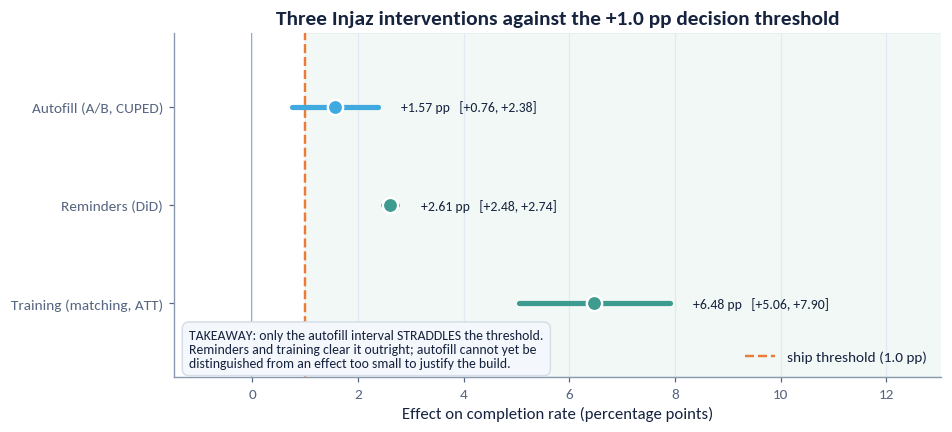

WHAT CANNOT BE DONE WITH THIS CHART
--------------------------------------------------------------------
These three numbers CANNOT be added. They are different estimands, on
different populations, resting on different assumptions:
  autofill  ATE on triggered users        - randomised, assumption-light
  reminders ATT on activated regions      - parallel trends
  training  ATT on self-selected enrollees - unconfoundedness, Gamma* ~ 1.2
A legitimate single figure for the board is TOTAL ATTRIBUTABLE COMPLETIONS
with a range, computed per intervention on its own population and summed with
its uncertainty - never a single averaged 'effect size'.


In [11]:
from causal_utils import decision_plot

ESTIMATES = [
    {"label": "Autofill (A/B, CUPED)", "estimate": eff_cuped.estimate,
     "ci_low": eff_cuped.ci_low, "ci_high": eff_cuped.ci_high},
    {"label": "Reminders (DiD)", "estimate": did_reminders.att,
     "ci_low": did_reminders.ci_low, "ci_high": did_reminders.ci_high},
    {"label": "Training (matching, ATT)", "estimate": att_training.att,
     "ci_low": att_training.ci_low, "ci_high": att_training.ci_high},
]
ax = decision_plot(ESTIMATES, threshold=plan.practical_threshold,
                   title="Three Injaz interventions against the +1.0 pp decision threshold")
ax.annotate(
    "TAKEAWAY: only the autofill interval STRADDLES the threshold.\n"
    "Reminders and training clear it outright; autofill cannot yet be\n"
    "distinguished from an effect too small to justify the build.",
    xy=(0.02, 0.03), xycoords="axes fraction", fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
plt.show()

print("WHAT CANNOT BE DONE WITH THIS CHART")
print("-" * 68)
print("These three numbers CANNOT be added. They are different estimands, on")
print("different populations, resting on different assumptions:")
print("  autofill  ATE on triggered users        - randomised, assumption-light")
print("  reminders ATT on activated regions      - parallel trends")
print("  training  ATT on self-selected enrollees - unconfoundedness, Gamma* ~ 1.2")
print("A legitimate single figure for the board is TOTAL ATTRIBUTABLE COMPLETIONS")
print("with a range, computed per intervention on its own population and summed with")
print("its uncertainty - never a single averaged 'effect size'.")

### Step 6b — Triangulation and the evidence ranking

Rank the three by **strength of evidence**, not by size of effect. The board will ask.

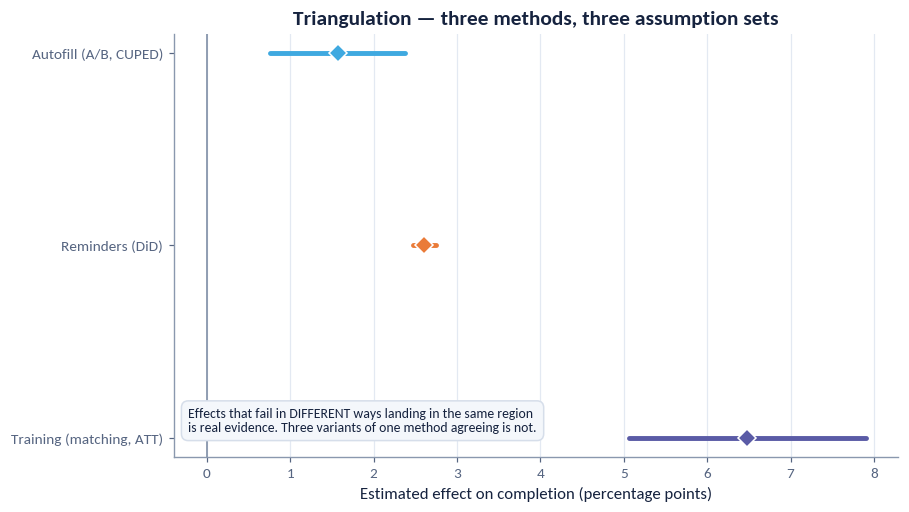


1_strongest:
  AUTOFILL (+1.57 pp) - randomised, SRM clean, balance clean, guardrails clean. The identifying assumption is a coin flip, which needs no defending. Weakest EFFECT, strongest EVIDENCE.

2_middle:
  REMINDERS (+2.61 pp) - quasi-experimental, but the assumption (parallel trends) is partly TESTABLE and it passed: flat pre-period, null placebo timing, and a clean not-yet-treated 2x2 that agrees.

3_weakest:
  TRAINING (+6.48 pp) - largest effect, weakest evidence. Unconfoundedness is untestable, motivation is unmeasured, and Rosenbaum bounds put the tolerance near Gamma = 1.2. Biggest number, least confidence.

why_ranking_not_effect_size:
  Effect size tells you how much a thing is worth IF the estimate is right. Evidence strength tells you how likely that is. A board allocating budget needs both, and the two rank in OPPOSITE order here - which is exactly the kind of thing an analyst must say out loud, because the slide with the biggest number will otherwise win the meeting.

In [12]:
from causal_utils import forest_plot

ax = forest_plot(ESTIMATES,
                 title="Triangulation — three methods, three assumption sets",
                 xlabel="Estimated effect on completion (percentage points)")
ax.annotate("Effects that fail in DIFFERENT ways landing in the same region\n"
            "is real evidence. Three variants of one method agreeing is not.",
            xy=(0.02, 0.06), xycoords="axes fraction", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.5", fc="#F4F7FB", ec="#D6DEEA"))
plt.show()

RANKING = {
    "1_strongest": (
        f"AUTOFILL ({100*eff_cuped.estimate:+.2f} pp) - randomised, SRM clean, balance "
        "clean, guardrails clean. The identifying assumption is a coin flip, which needs "
        "no defending. Weakest EFFECT, strongest EVIDENCE."),
    "2_middle": (
        f"REMINDERS ({100*did_reminders.att:+.2f} pp) - quasi-experimental, but the "
        "assumption (parallel trends) is partly TESTABLE and it passed: flat pre-period, "
        "null placebo timing, and a clean not-yet-treated 2x2 that agrees."),
    "3_weakest": (
        f"TRAINING ({100*att_training.att:+.2f} pp) - largest effect, weakest evidence. "
        "Unconfoundedness is untestable, motivation is unmeasured, and Rosenbaum bounds "
        "put the tolerance near Gamma = 1.2. Biggest number, least confidence."),
    "why_ranking_not_effect_size": (
        "Effect size tells you how much a thing is worth IF the estimate is right. "
        "Evidence strength tells you how likely that is. A board allocating budget needs "
        "both, and the two rank in OPPOSITE order here - which is exactly the kind of "
        "thing an analyst must say out loud, because the slide with the biggest number "
        "will otherwise win the meeting."),
}
for k, v in RANKING.items():
    print(f"\n{k}:\n  {v}")

> ### Instructor note — Step 6
>
> **Teaching point.** The inverse ranking of effect size and evidence strength is the single
> most useful thing a participant can take to their own organisation. Training has the biggest
> number and the weakest support; autofill the smallest and the strongest. Say it plainly.
>
> **The board case study lives here.** "Give us one number" → you cannot add these; you *can*
> give total attributable completions with a range, per intervention, on its own population.
> Make each pair compute one such figure if time allows.
>
> **Common wrong answer.** Averaging the three effects, or reporting the largest. Both are in
> the anti-pattern list.

## Step 7 — The verdict: statistical vs practical significance *(6 min)*

`practical_significance_verdict` maps a **confidence interval onto a decision**, not a p-value
onto a verdict. There are four cases and only one of them is *ship*.

| Interval | Verdict |
|---|---|
| entirely above the threshold | **SHIP** |
| entirely below zero | **STOP / ROLL BACK** |
| positive but entirely below the threshold | **HOLD** — real but too small |
| positive and **straddling** the threshold | **HOLD** — extend, or accept the risk |
| containing zero | **INCONCLUSIVE** |

In [13]:
from causal_utils import practical_significance_verdict

extra_days = None


def explain_verdict():
    global extra_days
    print(practical_significance_verdict(eff_cuped, plan.practical_threshold,
                                         "Autofill completion (CUPED)"))
    print()
    print(practical_significance_verdict(eff_raw, plan.practical_threshold,
                                         "Autofill completion (raw, sanity check)"))

    print("\n" + "=" * 72)
    print("WHY THIS IS 'HOLD' AND NOT 'SHIP' - the reasoning, spelled out")
    print("=" * 72)
    print(f"""
  p-value        : {eff_cuped.p_value:.4f}   -> statistically significant. The effect
                   is real; it is not zero.
  effect         : {100*eff_cuped.estimate:+.2f} pp -> above the {100*plan.practical_threshold:.1f} pp threshold
                   AS A POINT ESTIMATE.
  interval       : [{100*eff_cuped.ci_low:+.2f}, {100*eff_cuped.ci_high:+.2f}] pp
                   -> and here is the problem. The lower bound, {100*eff_cuped.ci_low:+.2f} pp,
                   sits BELOW the {100*plan.practical_threshold:.1f} pp threshold.

  In plain words: the data establish that autofill helps. They do NOT establish
  that it helps ENOUGH. Effects from {100*eff_cuped.ci_low:+.2f} pp (well short of the bar) to
  {100*eff_cuped.ci_high:+.2f} pp (comfortably over it) are all consistent with what we observed.

  'p < 0.05, ship it' answers the question 'is there an effect?'. The committee
  asked 'is the effect big enough to justify the build?'. Those are different
  questions and this experiment answers only the first.

  And we KNEW this in Step 2, before any outcome was looked at: the run collected
  {n_actual:,} per arm against the {n_required:,} the design required, so the smallest
  resolvable effect was {100*mde_actual:.2f} pp against a {100*plan.practical_threshold:.1f} pp threshold. The
  interval had to straddle. This is an under-run experiment, not an ambiguous
  feature.

  RECOMMENDATION: HOLD and EXTEND. Keep the test running to the designed sample.
""")

    n_to_resolve = int(np.ceil(
        n_actual * (eff_cuped.se
                    / ((eff_cuped.estimate - plan.practical_threshold) / 1.96)) ** 2))
    extra_days = int(np.ceil((2 * (n_to_resolve - n_actual))
                             / (traffic["eligible_users"].mean()
                                * traffic["trigger_rate"].mean())))
    extra_days += (7 - extra_days % 7) % 7
    print(f"  HOW MUCH LONGER: to move the lower bound above {100*plan.practical_threshold:.1f} pp at the")
    print(f"  currently observed effect size, roughly {n_to_resolve:,} per arm is needed")
    print(f"  ({n_to_resolve/n_actual:.1f}x the current sample) - about {extra_days} more days")
    print("  of traffic, rounded to whole weeks. That is the number to put to the")
    print(f"  committee: not 'we need more data', but '{extra_days // 7} more weeks and you get")
    print("  a decision either way'.")

    def _c():
        assert eff_cuped.ci_low < plan.practical_threshold < eff_cuped.ci_high, \
            "the autofill CI should STRADDLE the 1.0 pp threshold"
        assert eff_cuped.p_value < 0.05, "the effect should be statistically significant"
    check("verdict is HOLD: significant, but the CI straddles the threshold", _c)


if needs(eff_cuped, eff_raw, plan, n_actual, mde_actual):
    explain_verdict()

Autofill completion (CUPED): +1.57 pp [+0.76, +2.38]  vs threshold +1.0 pp
  VERDICT: HOLD — extend or accept the risk
  because significantly positive, but the interval straddles the 1.0 pp threshold, so the data cannot yet tell you whether the effect is worth shipping.

Autofill completion (raw, sanity check): +1.37 pp [+0.49, +2.24]  vs threshold +1.0 pp
  VERDICT: HOLD — extend or accept the risk
  because significantly positive, but the interval straddles the 1.0 pp threshold, so the data cannot yet tell you whether the effect is worth shipping.

WHY THIS IS 'HOLD' AND NOT 'SHIP' - the reasoning, spelled out

  p-value        : 0.0001   -> statistically significant. The effect
                   is real; it is not zero.
  effect         : +1.57 pp -> above the 1.0 pp threshold
                   AS A POINT ESTIMATE.
  interval       : [+0.76, +2.38] pp
                   -> and here is the problem. The lower bound, +0.76 pp,
                   sits BELOW the 1.0 pp threshold.

  I

> ### Instructor note — Step 7
>
> **This is the graded moment of the whole course.** A participant who writes "p < 0.05,
> ship it" has missed the point of four days. The correct answer is HOLD, and the reason must
> be the *interval against the threshold*, not the p-value against zero.
>
> **Run the debugging exercise here** (mini-exercise 1 below): hand out the wrong memo and
> have them rewrite the recommendation. It takes four minutes and it is the single highest-
> value drill in the module.
>
> **Common wrong answer #2.** "Not significant against the threshold, so no effect." Also
> wrong, in the opposite direction — the effect is real and significantly positive. The honest
> statement is about *what magnitudes remain compatible with the data*.
>
> **Expected output.** +1.57 pp [+0.76, +2.38], p = 0.0001, verdict "HOLD — extend or accept
> the risk"; roughly 2.0× the sample (≈ 50,000 per arm), about 7 more days — one whole week — to
> resolve it.

## Step 8 — The decision memo *(8 min)*

**The memo is the deliverable, not the notebook.** Effect sizes and intervals in business
units, one recommendation per intervention, assumptions stated as risks, and an explicit
"what would change this."

No p-values reach this page. A director cannot act on 0.0001; they can act on "between +0.8
and +2.4 points, and we need at least +1.0."

In [14]:
from causal_utils import decision_memo


class _E:
    def __init__(self, est, lo, hi):
        self.estimate, self.ci_low, self.ci_high = est, lo, hi


memo = decision_memo(
    title="AI form-autofill launch, and the regional reminder extension",
    decision=("(1) Launch AI-assisted form autofill to all Injaz users? "
              "(2) Extend the regional reminder programme nationally?"),
    estimates={
        "Autofill on completion (randomised A/B, CUPED-adjusted)":
            _E(eff_cuped.estimate, eff_cuped.ci_low, eff_cuped.ci_high),
        "Reminder programme on completion (difference-in-differences)":
            _E(did_reminders.att, did_reminders.ci_low, did_reminders.ci_high),
        "Training programme on completion, enrollees only (matching)":
            _E(att_training.att, att_training.ci_low, att_training.ci_high),
    },
    threshold=plan.practical_threshold,
    recommendation=(
        "AUTOFILL: HOLD and EXTEND, do not launch yet. The feature works and is safe - "
        f"it raises completion by {100*eff_cuped.estimate:+.2f} points and no guardrail is "
        "broken - but the run was stopped at "
        f"{100*(1 - n_actual/n_required):.0f}% short of its designed sample, so the range "
        f"({100*eff_cuped.ci_low:+.2f} to {100*eff_cuped.ci_high:+.2f} points) still "
        f"includes values below the {100*plan.practical_threshold:.1f}-point bar that "
        f"justifies the build. Roughly {extra_days} more days of traffic resolves it either "
        "way. Launching now is a bet, not a decision.\n"
        "        REMINDERS: SCALE. The effect clears the bar with room to spare and the "
        "identifying assumption was tested, not merely asserted.\n"
        "        TRAINING: EXPAND AS A MONITORED PILOT with randomised invitations. "
        "Largest measured effect, weakest evidence."),
    assumptions=[
        "AUTOFILL - randomised assignment by user id; sample-ratio and covariate-balance "
        "checks both pass, so no assumption beyond the randomisation itself is required.",
        "REMINDERS - parallel trends: activated regions would otherwise have moved with "
        "not-yet-activated ones. Supported by six flat pre-period months and a null "
        "placebo-timing test.",
        "TRAINING - unconfoundedness given measured characteristics. Untestable, and the "
        "obvious unmeasured driver (personal motivation) is not in our data.",
        "All three effects are on DIFFERENT populations and cannot be added into a single "
        "figure. Attributable completions per programme, with a range, is the legitimate "
        "way to give one number.",
    ],
    risks=[
        "The autofill test is under-run for its own decision threshold. This is a known "
        "and quantified limitation of the run, not an ambiguity in the feature.",
        "Support contacts rose slightly in the autofill arm (raw signal, not significant "
        "after correcting across the four guardrails). Worth monitoring during the "
        "extension; not a blocker.",
        "The reminder evaluation uses 13 regions. Cluster-robust intervals at that cluster "
        "count are indicative rather than exact.",
        "The training estimate would be overturned by an unmeasured driver of enrolment "
        "only moderately strong (odds ratio about 1.2). Treat the number as an upper "
        "estimate of what a national rollout would deliver.",
    ],
    what_would_change_this=[
        f"AUTOFILL: about {extra_days} more days at current traffic. If the lower bound "
        f"then clears {100*plan.practical_threshold:.1f} points, launch; if the upper bound "
        "falls below it, stop and reallocate the build.",
        "REMINDERS: evidence that a regional campaign coincided with reminder activation "
        "in any region - tell us and we re-run excluding it.",
        "TRAINING: a randomised invitation next quarter. Six weeks, no extra programme "
        "cost, and it replaces every assumption above with a coin flip.",
    ],
    plan=plan,
)
print(memo)

def _c():
    assert memo is not None, "memo is still None"
    assert "HOLD" in memo.upper(), "the recommendation for autofill must be HOLD"
    assert plan.plan_hash in memo, "the frozen-plan hash must appear in the memo"
    assert "p =" not in memo and "p-value" not in memo, "no p-values in a decision memo"
check("decision memo rendered with the frozen-plan hash and no p-values", _c)

DECISION MEMO — AI form-autofill launch, and the regional reminder extension
To: Injaz Product & Policy Committee
Date: 2026-09-07
Analysis plan frozen: 2026-09-07T17:21:39+00:00  (hash ca010dcd9d5a1387)

DECISION REQUESTED
(1) Launch AI-assisted form autofill to all Injaz users? (2) Extend the regional reminder programme nationally?

RECOMMENDATION
AUTOFILL: HOLD and EXTEND, do not launch yet. The feature works and is safe - it raises completion by +1.57 points and no guardrail is broken - but the run was stopped at 36% short of its designed sample, so the range (+0.76 to +2.38 points) still includes values below the 1.0-point bar that justifies the build. Roughly 7 more days of traffic resolves it either way. Launching now is a bet, not a decision.
REMINDERS: SCALE. The effect clears the bar with room to spare and the identifying assumption was tested, not merely asserted.
TRAINING: EXPAND AS A MONITORED PILOT with randomised invitations. Largest measured effect, weakest evidence.

W

True

> ### Instructor note — Step 8
>
> **Teaching point.** Read the memo aloud in the voice of a director. Everything that survives
> that reading is business language; everything that does not is analyst language. The
> `plan_hash` line at the top is process evidence — it proves the metrics were chosen before
> the results.
>
> **Peer review (6 min).** Exchange memos between pairs. The reviewer checks exactly four
> things and nothing else:
> 1. Is the effect given with an interval, in business units?
> 2. Is the recommendation compared to the **threshold**, not to zero?
> 3. Are the assumptions stated as **risks the reader can act on**?
> 4. Is there a concrete "what would change this"?
>
> **The most common memo failure** is a correct analysis with a recommendation of "the effect
> is +1.57 pp (p = 0.0001), we suggest proceeding." That memo scores in the < 70% band on the
> communication criterion regardless of how good the analysis was.

## Step 9 — Compare against the planted ground truth

In [15]:
import json
GT = json.loads((DATA / "GROUND_TRUTH.json").read_text())


def ground_truth_comparison():
    ga, g5, gp = (GT["capstone_autofill"], GT["module5_user_cohort"],
                  GT["module5_regions_panel"])
    rows = [
        {"quantity": "Autofill lift (triggered, raw)", "recovered_pp": 100*eff_raw.estimate,
         "planted_pp": 100*ga["true_lift_on_exposed"]},
        {"quantity": "Autofill lift (triggered, CUPED)",
         "recovered_pp": 100*eff_cuped.estimate, "planted_pp": 100*ga["true_lift_on_exposed"]},
        {"quantity": "Autofill lift (all assigned - DILUTED)",
         "recovered_pp": 100*eff_all.estimate, "planted_pp": float("nan")},
        {"quantity": "Reminder ATT (TWFE)", "recovered_pp": 100*did_reminders.att,
         "planted_pp": 100*gp["true_ATT"]},
        {"quantity": "Training ATT (matching)", "recovered_pp": 100*att_training.att,
         "planted_pp": 100*g5["true_ATT_training"]},
        {"quantity": "CUPED variance reduction (%)",
         "recovered_pp": 100*cuped.variance_reduction,
         "planted_pp": GT["module3_pre_period"]["expected_cuped_variance_reduction_pct"]},
    ]
    out = pd.DataFrame(rows)
    out["gap"] = out["recovered_pp"] - out["planted_pp"]
    print(out.to_string(index=False, float_format=lambda v: f"{v:+.2f}"))

    print(f"""
THE PLANTED DESIGN OF THIS EXPERIMENT
--------------------------------------
The autofill effect was planted at {100*ga['true_lift_on_exposed']:.1f} pp against a
{ga['ship_threshold_pp']:.1f} pp decision threshold, and the sample was chosen so the
confidence interval would STRADDLE that threshold. The dataset note says it
plainly: "the effect is real and statistically significant, yet the data cannot
establish that it is large enough to justify the build."

That is not a flaw in the data. It is the most common real situation in
industrial experimentation and the one that separates a p-value reader from a
decision partner. The correct answer is HOLD / EXTEND.

  recovered CUPED effect : {100*eff_cuped.estimate:+.2f} pp
  interval               : [{100*eff_cuped.ci_low:+.2f}, {100*eff_cuped.ci_high:+.2f}] pp
  threshold              : {100*plan.practical_threshold:+.2f} pp   <- inside the interval
  reminder DiD           : {100*did_reminders.att:+.2f} pp (planted {100*gp['true_ATT']:+.1f} pp full
                           effect; TWFE averages in the two-month ramp-in, so it
                           correctly lands below the mature effect - see Lab 5b)""")

    def _c():
        assert abs(eff_raw.estimate - ga["true_lift_on_exposed"]) < 0.003, \
            "raw autofill lift should match the planted +1.4 pp"
        assert eff_cuped.ci_low < ga["ship_threshold_pp"]/100 < eff_cuped.ci_high, \
            "the CI must straddle the threshold - that is the designed lesson"
        assert abs(att_training.att - g5["true_ATT_training"]) < 0.01, "training ATT off"
    check("all three effects recovered; the autofill CI straddles the threshold", _c)
    return out


if needs(eff_raw, eff_cuped, eff_all, did_reminders, att_training, cuped):
    comparison = ground_truth_comparison()

                              quantity  recovered_pp  planted_pp   gap
        Autofill lift (triggered, raw)         +1.37       +1.40 -0.03
      Autofill lift (triggered, CUPED)         +1.57       +1.40 +0.17
Autofill lift (all assigned - DILUTED)         +0.97         NaN   NaN
                   Reminder ATT (TWFE)         +2.61       +3.00 -0.39
               Training ATT (matching)         +6.48       +6.00 +0.48
          CUPED variance reduction (%)        +14.30      +13.50 +0.80

THE PLANTED DESIGN OF THIS EXPERIMENT
--------------------------------------
The autofill effect was planted at 1.4 pp against a
1.0 pp decision threshold, and the sample was chosen so the
confidence interval would STRADDLE that threshold. The dataset note says it
plainly: "the effect is real and statistically significant, yet the data cannot
establish that it is large enough to justify the build."

That is not a flaw in the data. It is the most common real situation in
industrial experimentation 

## What you now own

The **engagement template**. This is what the capstone asks you to reproduce on your own,
and what SDA-DSC-311 (Decision Science) consumes as its input.

In [16]:
def build_artefact():
    return {
        "notebook": "lab7 - full engagement: the autofill decision",
        "the_template": [
            "0. SELECT the method from the data situation, not from preference",
            "1. FRAME  - AnalysisPlan(...) + freeze_plan(...)  [before any outcome]",
            "2. POWER  - sample_size_proportions / run_length / cuped_adjust; and",
            "            compare what you NEEDED against what you HAVE (mde_for_n)",
            "3. VALIDATE INTEGRITY - srm_check on assigned AND on triggered; balance_table",
            "4. ANALYSE - the frozen OEC, CUPED-adjusted, robust SEs",
            "5. GUARDRAILS - the pre-registered family, the pre-registered correction",
            "6. RECONCILE - decision_plot + forest_plot against the threshold",
            "7. VERDICT - practical_significance_verdict: interval vs THRESHOLD",
            "8. MEMO   - decision_memo(...) with the plan hash, no p-values",
        ],
        "artefacts_for_the_capstone": [
            "frozen AnalysisPlan JSON + hash", "sizing table with the shortfall",
            "SRM + balance evidence", "guardrail table with the correction family",
            "decision plot vs threshold", "forest plot / triangulation",
            "one-page decision memo",
        ],
        "numbers_recovered": {
            "autofill_raw_pp": round(100*eff_raw.estimate, 2),
            "autofill_cuped_pp": round(100*eff_cuped.estimate, 2),
            "autofill_cuped_ci_pp": [round(100*eff_cuped.ci_low, 2),
                                     round(100*eff_cuped.ci_high, 2)],
            "autofill_all_assigned_pp": round(100*eff_all.estimate, 2),
            "threshold_pp": 100*plan.practical_threshold,
            "n_required_per_arm": n_required,
            "n_actual_per_arm": n_actual,
            "mde_resolvable_pp": round(100*mde_actual, 2),
            "cuped_variance_reduction": round(cuped.variance_reduction, 3),
            "reminders_did_pp": round(100*did_reminders.att, 2),
            "training_att_pp": round(100*att_training.att, 2),
            "verdict": "HOLD / EXTEND",
        },
        "rules_you_can_now_state": [
            "Steps 1-3 happen before you see outcomes. Step 4 follows the frozen plan.",
            "Compare the INTERVAL to the THRESHOLD, never the p-value to zero.",
            "'Not significant' is not 'no effect'; say what magnitudes remain compatible.",
            "Disagreement between methods is a finding, not an inconvenience.",
            "The memo is the deliverable. The notebook is the evidence behind it.",
            "A correct 'hold, keep running' is a better answer than a fast, wrong 'ship'.",
        ],
    }


if needs(eff_raw, eff_cuped, eff_all, did_reminders, att_training, cuped, mde_actual):
    ARTEFACT = build_artefact()
    for k, v in ARTEFACT.items():
        print(f"\n{k}:")
        print("  " + (("\n  ".join(str(x) for x in v)) if isinstance(v, list) else str(v)))


notebook:
  lab7 - full engagement: the autofill decision

the_template:
  0. SELECT the method from the data situation, not from preference
  1. FRAME  - AnalysisPlan(...) + freeze_plan(...)  [before any outcome]
  2. POWER  - sample_size_proportions / run_length / cuped_adjust; and
              compare what you NEEDED against what you HAVE (mde_for_n)
  3. VALIDATE INTEGRITY - srm_check on assigned AND on triggered; balance_table
  4. ANALYSE - the frozen OEC, CUPED-adjusted, robust SEs
  5. GUARDRAILS - the pre-registered family, the pre-registered correction
  6. RECONCILE - decision_plot + forest_plot against the threshold
  7. VERDICT - practical_significance_verdict: interval vs THRESHOLD
  8. MEMO   - decision_memo(...) with the plan hash, no p-values

artefacts_for_the_capstone:
  frozen AnalysisPlan JSON + hash
  sizing table with the shortfall
  SRM + balance evidence
  guardrail table with the correction family
  decision plot vs threshold
  forest plot / triangulation
  

## Mini exercises

### 1. Debugging — the memo that says SHIP *(5 min)*

A colleague submits this recommendation:

> *"Autofill increases completion by 1.57 percentage points with p = 0.0001, comfortably
> significant at the 5% level. The point estimate exceeds our 1.0-point threshold. We
> recommend shipping to all users."*

Every number in it is correct. The recommendation is wrong. **Rewrite it.**

In [17]:
ERROR_NAME = ("Confusing statistical significance (is the effect non-zero?) with "
              "practical significance (is the effect large enough to act on?), by "
              "comparing the POINT ESTIMATE rather than the INTERVAL to the threshold.")

REWRITE = f"""
Autofill raises completion by about {100*eff_cuped.estimate:.1f} points, and we are
confident the true gain lies somewhere between {100*eff_cuped.ci_low:.1f} and
{100*eff_cuped.ci_high:.1f} points. Our launch bar is {100*plan.practical_threshold:.1f} point,
and that bar sits INSIDE that range - so while we can say the feature helps, we
cannot yet say it helps enough to justify the build. No guardrail is broken, so
there is no risk in continuing to run. We recommend HOLDING the launch and
extending the test by about {extra_days} days, which at current traffic will move the
lower end of the range decisively above or below the bar. If the lower end clears
{100*plan.practical_threshold:.1f} point we launch; if the upper end falls below it we stop and
reallocate the engineering time.
"""
print("ERROR:", ERROR_NAME)
print(REWRITE)
print("Note what the rewrite does NOT contain: a p-value. Nothing was lost.")

ERROR: Confusing statistical significance (is the effect non-zero?) with practical significance (is the effect large enough to act on?), by comparing the POINT ESTIMATE rather than the INTERVAL to the threshold.

Autofill raises completion by about 1.6 points, and we are
confident the true gain lies somewhere between 0.8 and
2.4 points. Our launch bar is 1.0 point,
and that bar sits INSIDE that range - so while we can say the feature helps, we
cannot yet say it helps enough to justify the build. No guardrail is broken, so
there is no risk in continuing to run. We recommend HOLDING the launch and
extending the test by about 7 days, which at current traffic will move the
lower end of the range decisively above or below the bar. If the lower end clears
1.0 point we launch; if the upper end falls below it we stop and
reallocate the engineering time.

Note what the rewrite does NOT contain: a p-value. Nothing was lost.


### 2. Case study — "The Board Wants One Number" *(6 min)*

The steering board asks for **one figure** for the impact of last year's combined digital-
experience investments, to justify next year's budget.

Collapsing three estimands on three populations into one effect size would be misleading. But
"we can't" is not an acceptable answer to a board. Find the legitimate single figure.

In [18]:
POPULATIONS = {
    "Autofill (if launched, triggered users/yr)": 2_400_000,
    "Reminders (activated regions, users/yr)": 5_100_000,
    "Training (enrollees/yr)": 180_000,
}
eff_map = {
    "Autofill (if launched, triggered users/yr)": (eff_cuped.estimate, eff_cuped.ci_low,
                                                   eff_cuped.ci_high),
    "Reminders (activated regions, users/yr)": (did_reminders.att, did_reminders.ci_low,
                                                did_reminders.ci_high),
    "Training (enrollees/yr)": (att_training.att, att_training.ci_low, att_training.ci_high),
}
rows = []
for name, pop in POPULATIONS.items():
    e, lo, hi = eff_map[name]
    rows.append({"intervention": name, "population": pop,
                 "effect_pp": 100*e,
                 "completions_point": int(round(e*pop)),
                 "completions_low": int(round(lo*pop)),
                 "completions_high": int(round(hi*pop))})
attributable = pd.DataFrame(rows)
tot = attributable[["completions_point", "completions_low", "completions_high"]].sum()

print(attributable.to_string(index=False, float_format=lambda v: f"{v:,.2f}"))
print(f"\nTOTAL attributable additional completions per year:")
print(f"  central estimate : {tot['completions_point']:,}")
print(f"  plausible range  : {tot['completions_low']:,} to {tot['completions_high']:,}")

BOARD_ANSWER = f"""
BOARD ANSWER
------------
'Together these three programmes are worth roughly {tot['completions_point']/1000:.0f} thousand extra
completed services a year, and we would not be surprised by anything between
{tot['completions_low']/1000:.0f} and {tot['completions_high']/1000:.0f} thousand.'

That figure IS legitimate: each effect is applied to its own population and only
the resulting COUNTS - which share a unit - are added. The three effect SIZES are
not added, because they are different estimands on different populations.

Two caveats to state in the same breath:
  1. The autofill component is CONDITIONAL on launching, and we are recommending
     a hold pending four more weeks of data. Show the total with and without it.
  2. The training component carries the weakest evidence, so the true range is
     wider than the arithmetic suggests. If the board wants one conservative
     figure, give the total computed from each LOWER bound: {tot['completions_low']/1000:.0f} thousand.
"""
print(BOARD_ANSWER)

                              intervention  population  effect_pp  completions_point  completions_low  completions_high
Autofill (if launched, triggered users/yr)     2400000       1.57              37677            18239             57116
   Reminders (activated regions, users/yr)     5100000       2.61             133118           126269            139967
                   Training (enrollees/yr)      180000       6.48              11661             9104             14217

TOTAL attributable additional completions per year:
  central estimate : 182,456
  plausible range  : 153,612 to 211,300

BOARD ANSWER
------------
'Together these three programmes are worth roughly 182 thousand extra
completed services a year, and we would not be surprised by anything between
154 and 211 thousand.'

That figure IS legitimate: each effect is applied to its own population and only
the resulting COUNTS - which share a unit - are added. The three effect SIZES are
not added, because they are different

### 3. Discussion *(4 min)*

**(a)** When is a correct "hold and keep running" more valuable than a fast "ship"?

**(b)** How do you present a non-identifiable result so leadership still trusts the analysis?

In [19]:
DISCUSSION = {
    "a_hold_vs_ship": (
        "Whenever the cost of being wrong exceeds the cost of waiting. Shipping a feature "
        "whose true effect is below the bar spends engineering capacity permanently and "
        "sets a precedent that the bar is decorative; waiting four weeks costs four weeks. "
        "The asymmetry is even sharper in government, where a launched feature is very hard "
        "to withdraw. 'Hold' is also the only recommendation that ends with a DATE and a "
        "decision rule attached, which is what makes it actionable rather than indecisive."),
    "b_non_identifiable": (
        "Lead with what you CAN say, not what you cannot. 'Here is what we ruled out, here "
        "is what remains open, and here is the specific thing that would settle it.' Name "
        "the exact missing ingredient - an unmeasured confounder, an instrument, a "
        "randomised invitation - and price it: 'six weeks and no extra programme cost'. "
        "Leadership loses trust in analysts who produce confident wrong numbers, not in "
        "analysts who say 'not from this data, and here is the cheapest way to find out'."),
}
for k, v in DISCUSSION.items():
    print(f"\n{k}:\n  {v}")


a_hold_vs_ship:
  Whenever the cost of being wrong exceeds the cost of waiting. Shipping a feature whose true effect is below the bar spends engineering capacity permanently and sets a precedent that the bar is decorative; waiting four weeks costs four weeks. The asymmetry is even sharper in government, where a launched feature is very hard to withdraw. 'Hold' is also the only recommendation that ends with a DATE and a decision rule attached, which is what makes it actionable rather than indecisive.

b_non_identifiable:
  Lead with what you CAN say, not what you cannot. 'Here is what we ruled out, here is what remains open, and here is the specific thing that would settle it.' Name the exact missing ingredient - an unmeasured confounder, an instrument, a randomised invitation - and price it: 'six weeks and no extra programme cost'. Leadership loses trust in analysts who produce confident wrong numbers, not in analysts who say 'not from this data, and here is the cheapest way to find o

---

### Quiz recall (Module 7)

1. **First question when choosing a method?** → can we randomise going forward?
2. **Which steps must precede seeing outcomes?** → framing, design, powering, and freezing
   the plan.
3. **How should an effect be reported to leadership?** → effect size with a confidence
   interval in business units, plus a practical-significance verdict.
4. **What when experimental and observational estimates disagree?** → reconcile via the likely
   violated assumption; report both, do not cherry-pick.
5. **Is "we cannot conclude" ever a correct deliverable?** → yes, when justified, with what
   was ruled out and the concrete next step.

### Next

**The capstone.** Open `capstone_starter.ipynb`. It is this engagement, run by you, on the
full brief — plus one extension of your choice. Reuse everything in `ARTEFACT` above; that is
what it is for.